In [1]:
from model import DyMoTree
from utils import seed_all
seed_all(111, deterministic=True)

'''
 
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Data/scRNA/CART_tju/',
                 task='CART',
                 n_neighbor=50,
                 device='cuda')   
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Data/scLT/Weinreb/BiTree/desc246',
                 task='Larry',
                 n_neighbor=50,
                 device='cuda') 
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Data/scRNA/CD8/truth',
                 task='CD8',
                 n_neighbor=50,
                 device='cuda')   
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Project_Data/scRNA/mmEndoderm/Data.DyMoTree/',
                 task='mmE',
                 n_neighbor=40,
                 device='cuda')   
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Project_Data/scRNA/LungCancer/Data.DyMoTree/',
                 task='LC',
                 n_neighbor=50,
                 device='cuda')   
       
'''
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Project_Data/scRNA/mmEndoderm/Data.DyMoTree/',
                 task='mmE',
                 n_neighbor=40,
                 device='cuda')   

[2025-10-30 11:20:35] loading node data for ICM
[2025-10-30 11:20:36] loading node data for PrE
[2025-10-30 11:20:37] loading node data for EPI
[2025-10-30 11:20:38] calculate shortest distance for ICM with all descendant


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:    0.6s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  47 out of  64 | elapsed:    0.6s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  54 out of  64 | elapsed:    0.6s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  61 out of  64 | elapsed:    0.6s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.6s finished


[2025-10-30 11:20:39] loading edge data for ICM


In [3]:
seed_all(111, deterministic=True)
dmt.train(
        lamda1=0.5,lamda2=0.5,lamda3=0.1,lamda4=0,
        k=1e-4, # best: 0
        c=1,  # best: 0.1
        e=0,   # best: 10
        b=0, # best: 1e-4
        n_iter=200,
        pre_iter=200,
        lr=1e-4,
        pre_lr=1e-5)
dmt.get_fate_sapce()

:: Do pre-train Graph encoder for ICM::


100%|█████████████████████████████████████████████████| 100/100 [00:05<00:00, 19.05it/s, loss=0.695]


:: Do pre-train Graph encoder for PrE::


100%|█████████████████████████████████████████████████| 100/100 [00:02<00:00, 40.83it/s, loss=0.777]


:: Do pre-train Graph encoder for EPI::


...

:: DyMoTree stage1 tranning ::


Iter: 200/200 : 100%|█████████████████████████████████| 200/200 [00:16<00:00, 12.19it/s, loss=0.797]


:: DyMoTree stage2 tranning ::


Iter: 200/200 : 100%|██████████████████████████████████| 200/200 [00:35<00:00,  5.58it/s, loss=1.05]


[2025-10-30 11:22:53] get fate space of ICM


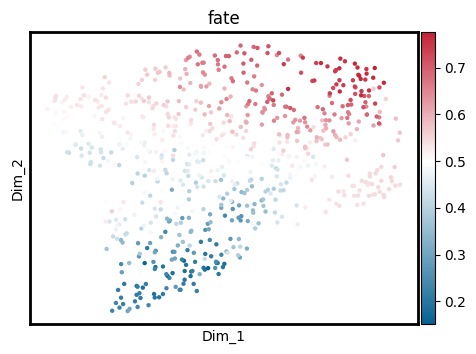

In [ ]:
import scanpy as sc
import pandas as pd 
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
dmt.tree_data.G.nodes['ICM']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['ICM']['data'].adata.obs['EPI_fate']/(dmt.tree_data.G.nodes['ICM']['data'].adata.obs['PrE_fate']+dmt.tree_data.G.nodes['ICM']['data'].adata.obs['EPI_fate'])
dmt.tree_data.G.nodes['ICM']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['ICM']['prior_list']['prior'])['EPI'].values/(pd.DataFrame(dmt.tree_data.tree['ICM']['prior_list']['prior'])['PrE'].values+pd.DataFrame(dmt.tree_data.tree['ICM']['prior_list']['prior'])['EPI'].values)

median_loc = np.where(dmt.tree_data.G.nodes['ICM']['data'].adata.obs['fate']<0.5)[0].shape[0]/dmt.tree_data.G.nodes['ICM']['data'].adata.obs.shape[0]
if median_loc<0.5:
    correct_loc = 1-median_loc
else:
    correct_loc = median_loc


custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (correct_loc,"white"), (1,"#c42238")]
)
state_color = {
    'Child1_fate': '#b1d7f2',
    'Child2_fate': '#f8cbe0',
    'Stem': '#64499d'
}
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        dmt.tree_data.G.nodes['ICM']['data'].adata,
        x='Dim_1',
        y='Dim_2',
        color='fate', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

In [32]:
# find cell state
dmt.find_state(n_state=3,
               n_pca=10,
               n_diff=10,
               n_gene=10,
               method='spearman')

[2025-10-30 11:38:41] find cell state of ICM
[2025-10-30 11:38:42] Filtering Data by fate space


/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


[2025-10-30 11:38:45] PCA transformation
[2025-10-30 11:38:46] Run Diffusion map
[2025-10-30 11:38:48] Find archetypes


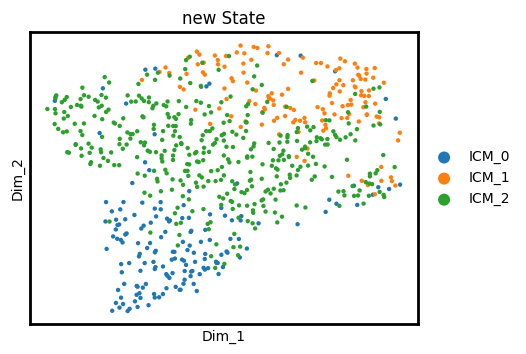

In [33]:
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        dmt.tree_data.G.nodes['ICM']['data'].adata,
        x='Dim_1',
        y='Dim_2',
        color='new_State', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

/tmp/ipykernel_2054727/1835885006.py:18: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].replace(replacement_map)


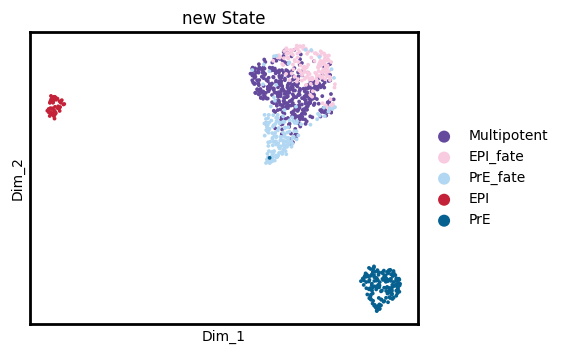

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import scanpy as sc
import anndata
import pandas as pd

adata_merged = anndata.concat(
    [dmt.tree_data.G.nodes[cell]['data'].adata for cell in dmt.init_tree.keys()]
)
adata_to_plot = adata_merged.copy()

# rename DyMoTree Cell State
import pandas as pd
replacement_map = {'ICM_2': 'Multipotent', 'ICM_0': 'PrE_fate','ICM_1':'EPI_fate','EPI':'EPI','PrE':'PrE'}
new_order = ['Multipotent','EPI_fate','PrE_fate','EPI','PrE']
adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].astype('category')
adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].replace(replacement_map)
adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))

adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].astype('category')
new_order = ['Multipotent', 'EPI_fate', 'PrE_fate','EPI','PrE']
adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype('category')
new_order = ['ICM','EPI','PrE']
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))


color_map_state = {
    'PrE_fate': '#b1d7f2',
    'Multipotent': '#64499d',
    'EPI_fate': '#f8cbe0',
    'PrE':'#066190',
    'EPI':'#c42238'
}
state_color_list = [color_map_state[cat] for cat in adata_to_plot.obs['new_State'].cat.categories]
adata_to_plot.uns['new_State_colors'] = state_color_list

color_map_celltype = {
    'ICM': '#64499d',
    'PrE':'#066190',
    'EPI':'#c42238'
}
celltype_color_list = [color_map_celltype[cat] for cat in adata_to_plot.obs['lineage'].cat.categories]
adata_to_plot.uns['lineage_colors'] = celltype_color_list


with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        adata_to_plot,
        x='Dim_1',
        y='Dim_2',
        color='new_State',  
        size=30,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

In [ ]:
dmt.save_model('./Fig3/dmt.pt')
adata_to_plot.write('./Fig3/mmE_dmt.h5ad')
dmt.tree_data.G.nodes['ICM']['data'].adata.write('./Fig3/ICM_dmt.h5ad')

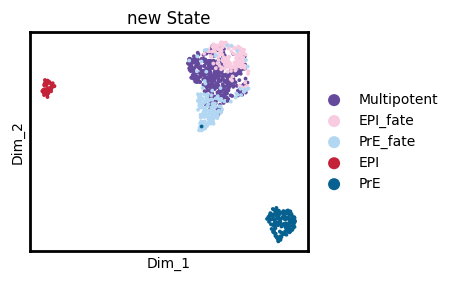

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

tree = sc.read('./Fig3/mmE_dmt.h5ad')
stem = sc.read('./Fig3/ICM_dmt.h5ad')

median_loc = np.where(stem.obs['fate']<0.5)[0].shape[0]/stem.obs.shape[0]
if median_loc<0.5:
    correct_loc = 1-median_loc
else:
    correct_loc = median_loc
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (correct_loc,"white"), (1,"#c42238")]
)
color_map_state = {
    'PrE_fate': '#b1d7f2',
    'Multipotent': '#64499d',
    'EPI_fate': '#f8cbe0',
    'PrE':'#066190',
    'EPI':'#c42238'
}
state_color_list = [color_map_state[cat] for cat in tree.obs['new_State'].cat.categories]
tree.uns['new_State_colors'] = state_color_list
color_map_celltype = {
    'ICM': '#64499d',
    'PrE':'#066190',
    'EPI':'#c42238'
}
celltype_color_list = [color_map_celltype[cat] for cat in tree.obs['lineage'].cat.categories]
tree.uns['lineage_colors'] = celltype_color_list

with rc_context({'figure.figsize': (4, 3)}):
    ax = sc.pl.scatter(
        tree,
        x='Dim_1',
        y='Dim_2',
        color='new_State', 
        size=30,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig("./Fig3/mmE.fate_state.png",bbox_inches='tight')
    plt.show()

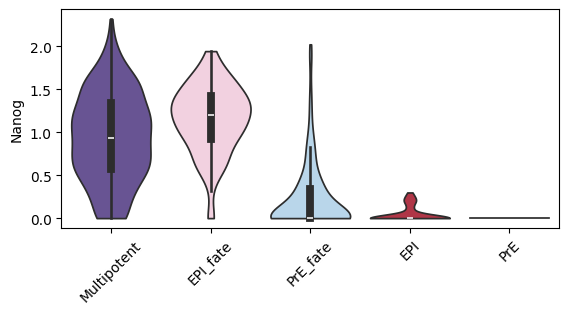

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

tree = sc.read('./Fig3/mmE_dmt.h5ad')
#stem = sc.read('D:/scRNA/mmEndoderm/Result.DyMoTree.10.14/ICM_dmt.h5ad')
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        tree,
        ['Nanog'],
        groupby='new_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig("./Fig3/mmE.nanog_expression.png",bbox_inches='tight')
    plt.show()

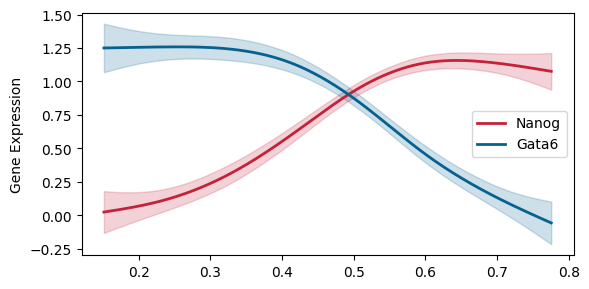

<Figure size 640x480 with 0 Axes>

In [25]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

stem = sc.read('./Fig3/ICM_dmt.h5ad')

from plotting import plot_feature_trend
features = ['Nanog','Gata6']
color_map = {features[0]:"#c42238",features[1]:"#066190"}

#features = ['Elane','Gfi1','Mpo']
#color_map = {features[0]:'#fd738a',features[1]:'#fea6b6',features[2]:'#ff4a4a'}
ax = plot_feature_trend(stem,'fate',features,color_map,lin_space=1000,n_splines=10,lam=10,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(6, 3))
plt.savefig("./Fig3/mmE.EPI_PrE_marker_trends.pdf",bbox_inches='tight')
plt.show()

In [1]:
# Find Driver
import scanpy as sc
import pandas as pd
from model import DyMoTree
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Project_Data/scRNA/mmEndoderm/Data.DyMoTree/',
                 task='mmE',
                 n_neighbor=40,
                 device='cuda')  
dmt.load_model('./Fig3/dmt.pt')
dmt.get_fate_sapce()
driver_result = dmt.find_driver(ancestor='ICM',
                top_n=100,
                soft_treshold=1,
                graph_threshold=0.,
                method='pearson',
                model='lasso',
                lasso_alpha=0.05
                )

[2025-10-30 13:08:06] loading node data for ICM
[2025-10-30 13:08:08] loading node data for PrE
[2025-10-30 13:08:09] loading node data for EPI
[2025-10-30 13:08:10] calculate shortest distance for ICM with all descendant


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  47 out of  64 | elapsed:    0.5s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  54 out of  64 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  61 out of  64 | elapsed:    0.5s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.5s finished


[2025-10-30 13:08:11] loading edge data for ICM
[2025-10-30 13:08:12] get fate space of ICM


/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[2025-10-30 13:08:14]Do regression
[2025-10-30 13:08:15] convolution by co-expression network


In [3]:
driver_result.coef.sort_values(by='EPI',ascending=False).head(30)

,PrE,EPI
Zfp42,0.0,0.001328
Fgf4,0.0,0.000772
Kdm5b,0.0,0.000740
Nanog,0.0,0.000729
Morc1,0.0,0.000694
Sox2,0.0,0.000672
Avpi1,0.0,0.000656
Tdgf1,0.0,0.000628
Klf2,0.0,0.000607
Rnf213,0.0,0.000568


In [4]:
driver_result.coef.to_csv('./Fig3/mmE_ICM_driver_score.csv')

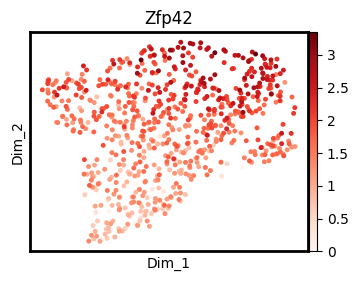

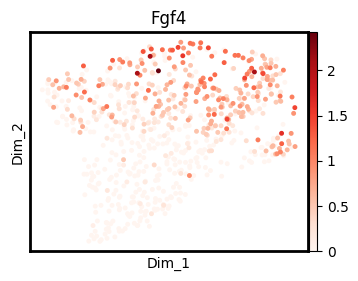

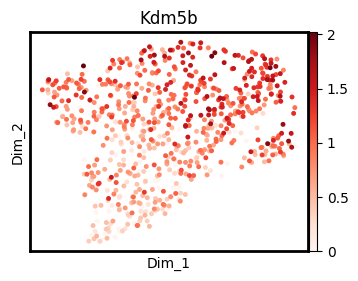

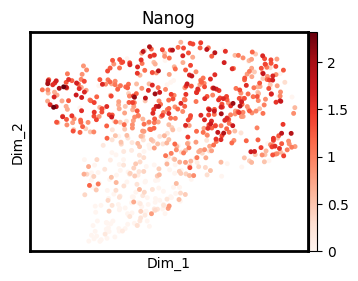

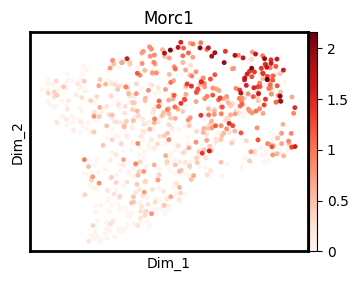

In [20]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

stem = sc.read('./Fig3/ICM_dmt.h5ad')
num_gene = 5
fate = 'EPI'
'''
gene = driver_result.coef.sort_values(by=fate,ascending=False).iloc[0:num_gene,:].index.tolist()
sc.pl.scatter(
            stem,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=50,
            color_map='Reds',
            frameon=False,
            show=True
        )
'''
for i in range(num_gene):
    gene = driver_result.coef.sort_values(by=fate,ascending=False).iloc[0:num_gene,:].index.tolist()[i]
    with rc_context({'figure.figsize': (4, 3)}):
        ax = sc.pl.scatter(
            stem,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=50,
            color_map='Reds',
            frameon=False,
            show=False
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        plt.savefig(f"./Fig3/mmE.{fate}_{gene}_featureplot.png",bbox_inches='tight')
        plt.show()

[2025-10-30 13:21:14] loading node data for ICM
[2025-10-30 13:21:15] loading node data for PrE
[2025-10-30 13:21:16] loading node data for EPI
[2025-10-30 13:21:18] calculate shortest distance for ICM with all descendant
[2025-10-30 13:21:18] loading edge data for ICM


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.021296977996826172s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  19 out of  64 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  26 out of  64 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  54 out of  64 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.1s finished


[2025-10-30 13:21:19] get fate space of ICM


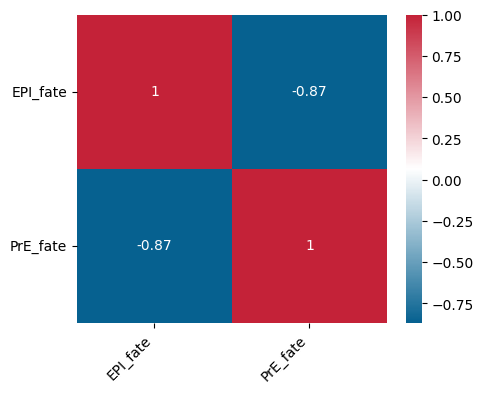

In [23]:
# check fate correlation

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from model import DyMoTree
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Project_Data/scRNA/mmEndoderm/Data.DyMoTree/',
                 task='mmE',
                 n_neighbor=40,
                 device='cuda') 
dmt.load_model('./Fig3/dmt.pt')
dmt.get_fate_sapce()


colors = ["#066190", "white", "#c42238"]
cmap = LinearSegmentedColormap.from_list('custom_red_white_blue', colors, N=256)
#norm = DivergingNorm(vcenter=0)

cor_mat = dmt.tree_data.G.nodes['ICM']['data'].adata.obs.loc[:,['EPI_fate','PrE_fate']].corr()
column_names = ['EPI_fate','PrE_fate']
row_names = ['EPI_fate','PrE_fate']
df = pd.DataFrame(data=cor_mat, index=row_names, columns=column_names)

plt.figure(figsize=(5, 4))
# Seaborn的barplot会返回一个Axes对象
ax = sns.heatmap(df,annot=True,cmap=cmap)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.savefig("./Fig3/mmE.fate_correlation.pdf",bbox_inches='tight')
plt.show()

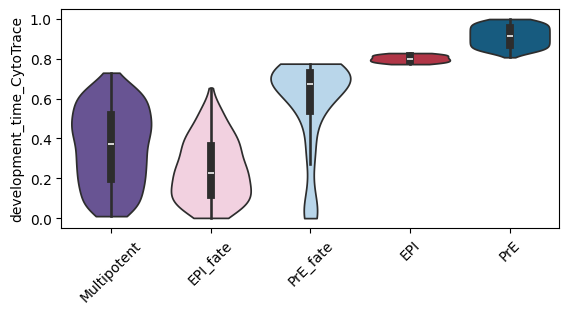

In [1]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
tree = sc.read('./Fig3/mmE_dmt.h5ad')
stem = sc.read('./Fig3/ICM_dmt.h5ad')

cytotrace = pd.read_csv('./Fig3/ICM.CytoTrace.Score.csv')
entropy_res = pd.read_csv('./Fig3/entropy.csv')
tree.obs['development_time_CytoTrace'] = cytotrace['x'].values
tree.obs['Stemness_score_CytoTrace'] = 1-cytotrace['x'].values
tree.obs['development_time_WOT'] = 1-entropy_res['entropy_WOT'].values
tree.obs['Stemness_score_WOT'] = entropy_res['entropy_WOT'].values
tree.obs['development_time_FateID'] = 1-entropy_res['entropy_FateID'].values
tree.obs['Stemness_score_FateID'] = entropy_res['entropy_FateID'].values
tree.obs['development_time_CellRank'] = 1-entropy_res['entropy_CellRank'].values
tree.obs['Stemness_score_CellRank'] = entropy_res['entropy_CellRank'].values
tree.obs['development_time_Palantir'] = 1-entropy_res['entropy_Palantir'].values
tree.obs['Stemness_score_Palantir'] = entropy_res['entropy_Palantir'].values
stem.obs['development_time_CytoTrace'] = tree.obs.loc[tree.obs['lineage']=='ICM','development_time_CytoTrace'].values
stem.obs['Stemness_score_CytoTrace'] = tree.obs.loc[tree.obs['lineage']=='ICM','Stemness_score_CytoTrace'].values
stem.obs['development_time_WOT'] = tree.obs.loc[tree.obs['lineage']=='ICM','development_time_WOT'].values
stem.obs['Stemness_score_WOT'] = tree.obs.loc[tree.obs['lineage']=='ICM','Stemness_score_WOT'].values
stem.obs['development_time_FateID'] = tree.obs.loc[tree.obs['lineage']=='ICM','development_time_FateID'].values
stem.obs['Stemness_score_FateID'] = tree.obs.loc[tree.obs['lineage']=='ICM','Stemness_score_FateID'].values
stem.obs['development_time_Palantir'] = tree.obs.loc[tree.obs['lineage']=='ICM','development_time_Palantir'].values
stem.obs['Stemness_score_Palantir'] = tree.obs.loc[tree.obs['lineage']=='ICM','Stemness_score_Palantir'].values
stem.obs['development_time_CellRank'] = tree.obs.loc[tree.obs['lineage']=='ICM','development_time_CellRank'].values
stem.obs['Stemness_score_CellRank'] = tree.obs.loc[tree.obs['lineage']=='ICM','Stemness_score_CellRank'].values

gene = 'development_time_CytoTrace'
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        tree,
        gene,
        groupby='new_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig(f"./Fig2/1.Larry.DMT.bench.result/Larry.fate_state.CytoTrace.png",bbox_inches='tight')
    plt.show()

In [2]:
import pandas as pd
from scipy.stats import entropy
import numpy as np
prob_values = stem.obs[['PrE_fate', 'EPI_fate']].values/stem.obs[['PrE_fate', 'EPI_fate']].values.sum(axis=1,keepdims=True)
stem.obs['Stemness_score_DyMoTree'] = entropy(prob_values, axis=1, base=2)
stem.obs['development_time_DyMoTree'] = 1-entropy(prob_values, axis=1, base=2)

In [10]:
cospar_res = pd.read_csv('./Fig3/cospar_res.csv')
cospar_res = cospar_res[cospar_res['CellType'].isin(['ICM'])]
prob_values = cospar_res[['fate_map_transition_map_EPI', 'fate_map_transition_map_PrE']].values/cospar_res[['fate_map_transition_map_EPI', 'fate_map_transition_map_PrE']].values.sum(axis=1,keepdims=True)
stem.obs['Stemness_score_CoSpar'] = entropy(prob_values, axis=1, base=2)
stem.obs['development_time_CoSpar'] = 1-entropy(prob_values, axis=1, base=2)

Pearson's r (相关系数): 0.3601
P-value (P值): 0.0000


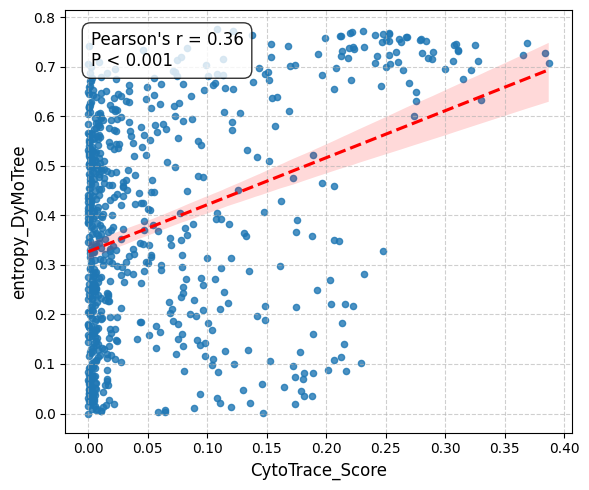

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

df = stem.obs[['CytoTrace_score','entropy_DyMoTree','entropy_WOT','entropy_FateID','entropy_CellRank','entropy_Palantir']]
# ----------------------------------------------------


# --- 2. 计算相关性 (r) 和 P 值 ---
# 使用 scipy.stats.pearsonr
# 它返回 (相关系数r, P值)
r, p = stats.pearsonr(df['entropy_DyMoTree'], df['CytoTrace_score'])

print(f"Pearson's r (相关系数): {r:.4f}")
print(f"P-value (P值): {p:.4f}")


# --- 3. 绘制散点图 ---
# 设置画布大小
plt.figure(figsize=(6, 5))

# 使用 seaborn 的 regplot，它会自动绘制散点图和回归线
ax = sns.regplot(
    data=df,
    x='entropy_DyMoTree',
    y='CytoTrace_score',
    scatter_kws={'s': 20, 'alpha': 0.8}, # 设置点的大小和透明度
    line_kws={'color': 'red', 'linestyle': '--'} # 设置回归线的颜色和样式
)

# --- 4. 在图上添加注释 (R值和P值) ---

# 准备注释文本
# (我们对P值进行格式化，如果太小，就显示 < 0.001)
p_text = f"P < 0.001" if p < 0.001 else f"P-value = {p:.3f}"
annotation_text = f"Pearson's r = {r:.2f}\n{p_text}"

# 使用 plt.text() 添加文本
# transform=ax.transAxes 表示使用相对于“坐标轴”的坐标系 (0,0)是左下角, (1,1)是右上角
# 这样无论你的数据范围如何，文本总是在固定的位置
plt.text(
    0.05, 0.95, # 放在左上角 (x=5%, y=95%)
    annotation_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top', # 垂直对齐方式
    # 添加一个白色背景框，使文本更清晰
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
)


# --- 5. 美化和显示图像 ---
plt.xlabel('CytoTrace_Score', fontsize=12)
plt.ylabel('entropy_DyMoTree', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # 添加网格线
plt.tight_layout() # 自动调整布局
#plt.savefig(f"./Fig2/1.Larry.DMT.bench.result/Larry.Entropy.CytoTrace.corr.pdf",bbox_inches='tight')
plt.show()

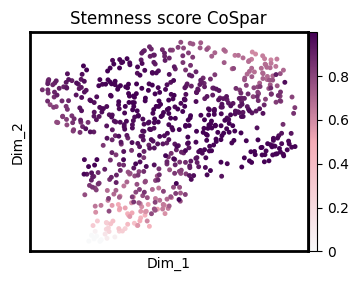

In [ ]:
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#f8f9fa"), (0.5,"#f4acb7"),(1,'#440154')]
)
metric = 'Stemness_score_CoSpar'
with rc_context({'figure.figsize': (4, 3)}):
    ax = sc.pl.scatter(
            stem,
            x='Dim_1',
            y='Dim_2',
            color=metric, 
            size=50,
            color_map=custom_bwr,
            frameon=False,
            show=False)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig(f"./Fig3/mmE.{metric}.pdf",bbox_inches='tight')
    plt.show()

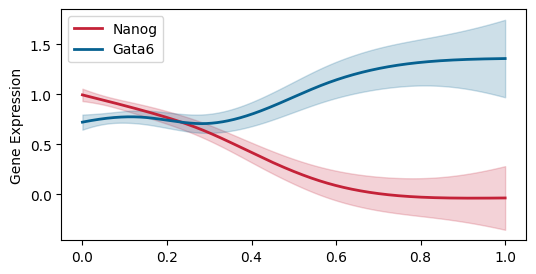

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
metric = 'development_time_CoSpar'
#stem = sc.read('./Fig3/ICM_dmt.h5ad')
from plotting import plot_feature_trend
features = ['Nanog','Gata6']
color_map = {features[0]:"#c42238",features[1]:"#066190"}

#features = ['Elane','Gfi1','Mpo']
#color_map = {features[0]:'#fd738a',features[1]:'#fea6b6',features[2]:'#ff4a4a'}
ax = plot_feature_trend(stem,metric,features,color_map,lin_space=1000,n_splines=10,lam=10,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(6, 3),show=False)
#plt.savefig(f"./Fig3/ICM.Driver_trends.{metric}.pdf",bbox_inches='tight')
plt.show()

In [ ]:
# PrE 相关基因
genes_pre = driver_result.coef.sort_values(by='PrE',ascending=False).head(30).index.tolist()

# EPI 相关基因
genes_epi = driver_result.coef.sort_values(by='EPI',ascending=False).head(30).index.tolist()
import numpy as np
adata = dmt.tree_data.G.nodes['ICM']['data'].adata.copy()
# 按 fate_score 从低到高排序
adata_sorted = adata[adata.obs['fate'].argsort()].copy()
genes_all = genes_pre + genes_epi[::-1]
import scanpy as sc
adata_sorted.obs['all_cells'] = 'ICM'
sc.pl.heatmap(
    adata_sorted,
    var_names=genes_all,
    groupby='all_cells',
    swap_axes=True,        # 基因在 y 轴
    standard_scale="var",  # 强烈推荐
    show_gene_labels=True,
    cmap="Reds"         # 可选，默认也可以
)

In [ ]:
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

# ------------------
# gene class & colors
# ------------------
gene_class = {}
for g in genes_pre:
    gene_class[g] = 'pre'
for g in genes_epi:
    gene_class[g] = 'epi'

colors = {
    'pre': '#066190',   # PrE
    'epi': '#c42238'    # EPI
}
# ------------------
# x axis
# ------------------
x = adata.obs['fate'].values
x_grid = np.linspace(0, 1, 200)

# ------------------
# store class-level predictions
# ------------------
class_preds = {
    'pre': [],
    'epi': []
}

plt.figure(figsize=(6, 4))

# ------------------
# per-gene GAM fitting
# ------------------
for gene in genes_pre + genes_epi:
    y = adata[:, gene].X
    if hasattr(y, "toarray"):
        y = y.toarray().flatten()
    else:
        y = y.flatten()

    # gene-wise scaling
    y = StandardScaler().fit_transform(y[:, None]).flatten()

    gam = LinearGAM(s(0, n_splines=10)).fit(x[:, None], y)

    y_pred = gam.predict(x_grid)
    y_ci = gam.prediction_intervals(x_grid, width=0.95)

    cls = gene_class[gene]
    c = colors[cls]

    # store prediction for class-average curve
    class_preds[cls].append(y_pred)

    # 置信区间（最底层）
    plt.fill_between(
        x_grid,
        y_ci[:, 0],
        y_ci[:, 1],
        color=c,
        alpha=0.01,
        zorder=1
    )

    # 单基因趋势线（浅色，中层）
    plt.plot(
        x_grid,
        y_pred,
        color=c,
        alpha=0.1,
        linewidth=1,
        zorder=2
    )

# ------------------
# class-average curves（深色，最上层）
# ------------------
for cls in ['pre', 'epi']:
    mean_pred = np.mean(class_preds[cls], axis=0)
    plt.plot(
        x_grid,
        mean_pred,
        color=colors[cls],
        linewidth=3,
        alpha=1.0,
        zorder=5
    )

# ------------------
# legend
# ------------------
legend_elements = [
    Line2D([0], [0], color=colors['pre'], lw=3, label='PrE-biased genes'),
    Line2D([0], [0], color=colors['epi'], lw=3, label='EPI-biased genes')
]

plt.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)


# ------------------
# labels & layout
# ------------------
plt.xlabel("Fate bias")
plt.ylabel("Gene expression")

plt.tight_layout()
plt.show()
